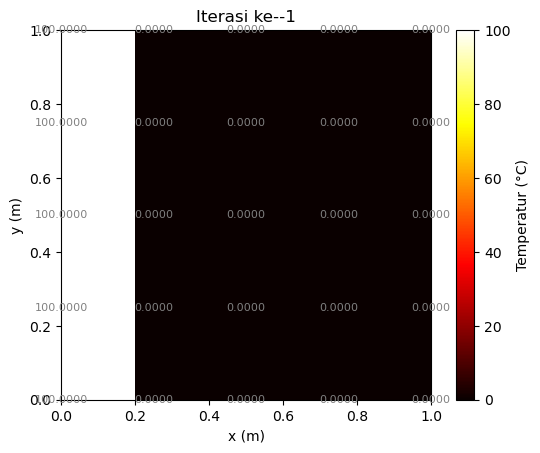

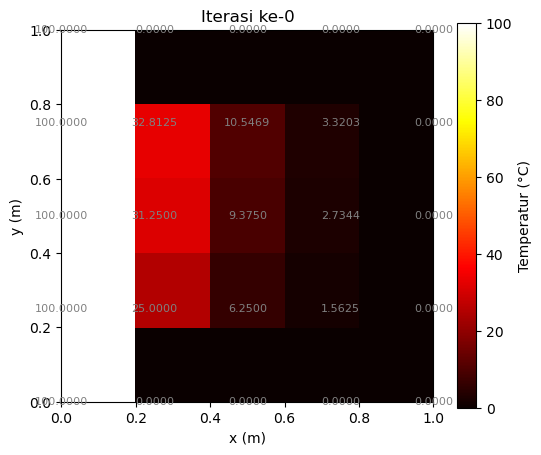

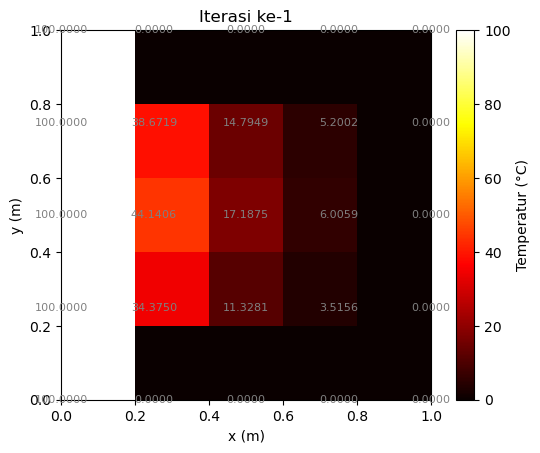

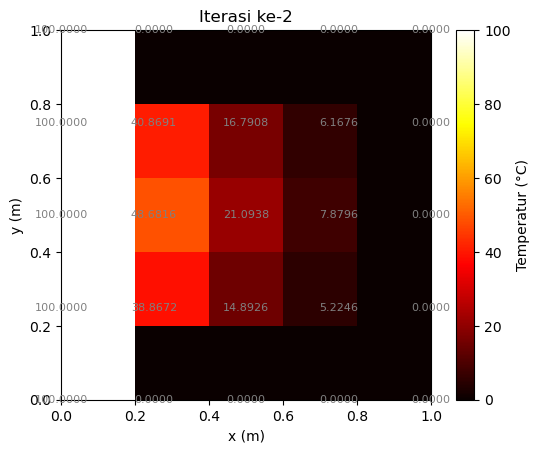

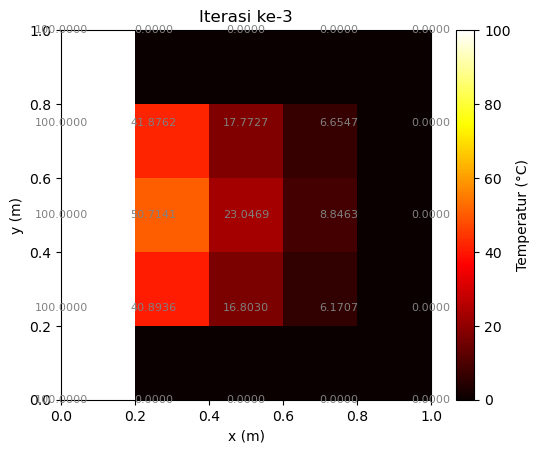

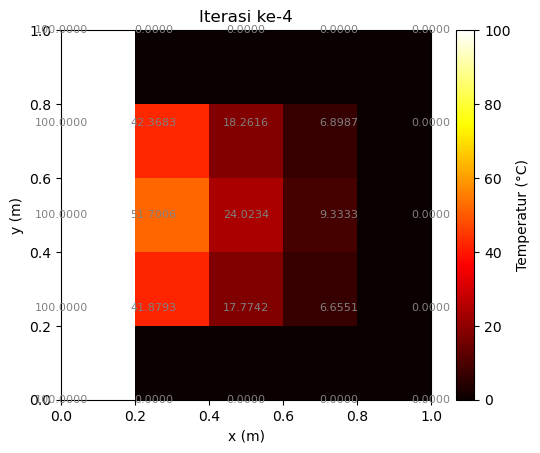

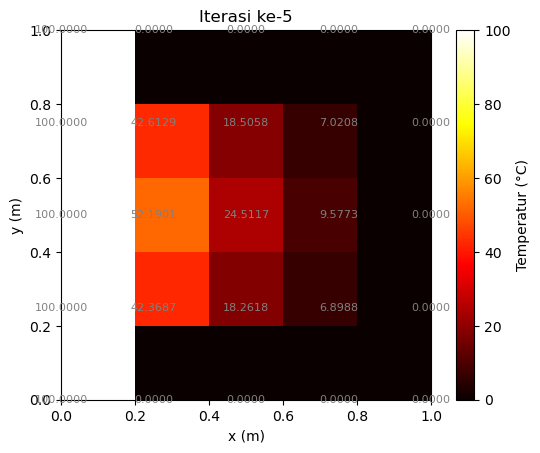

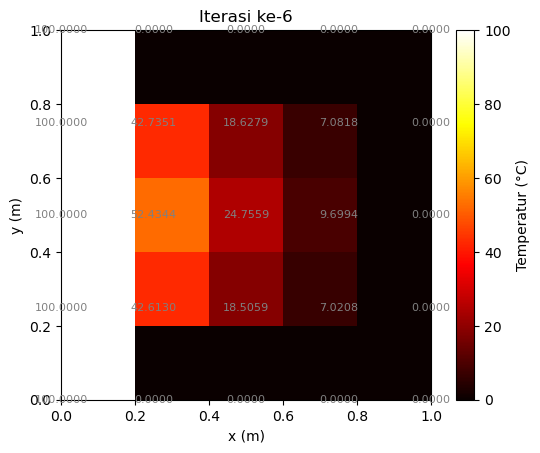

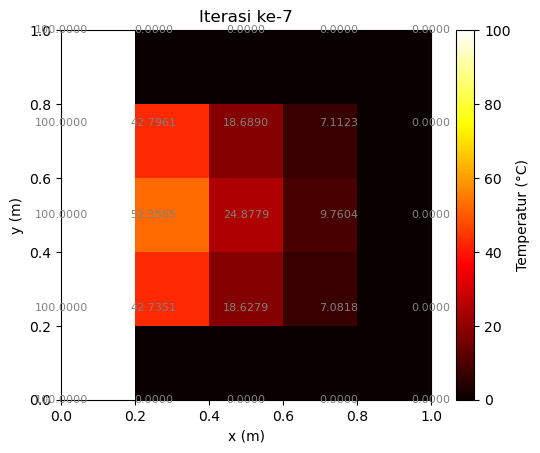

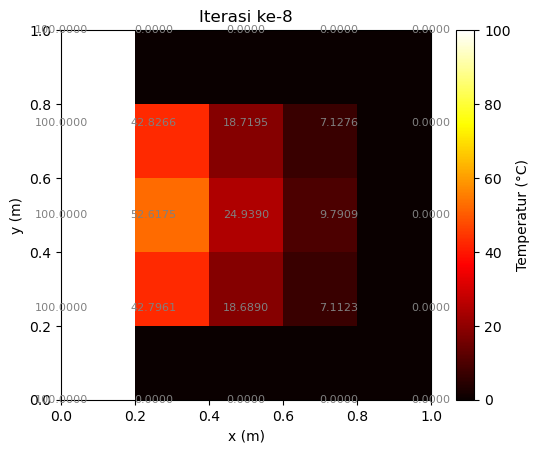

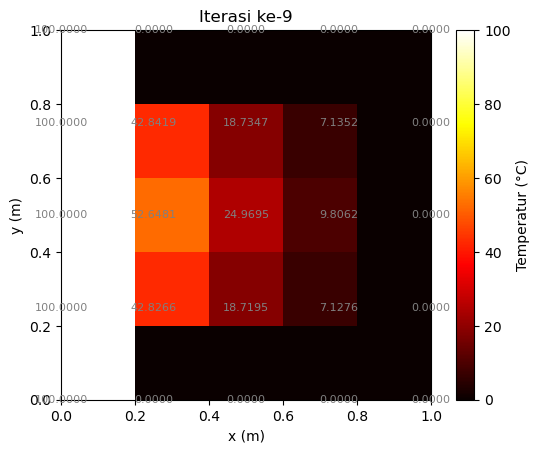

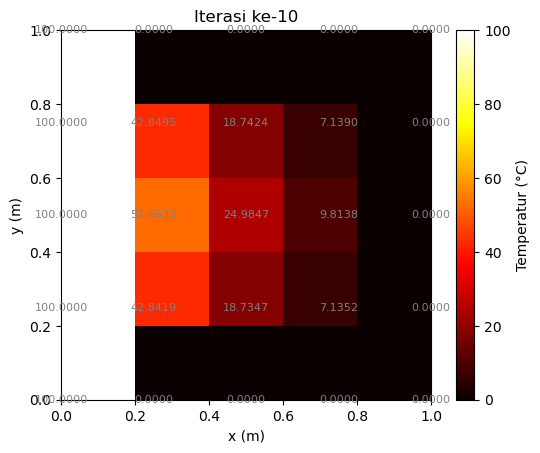

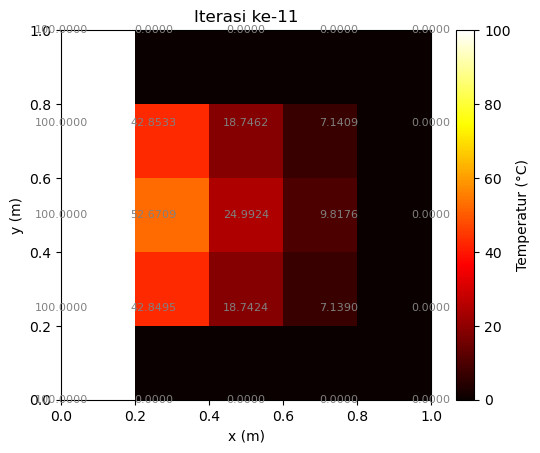

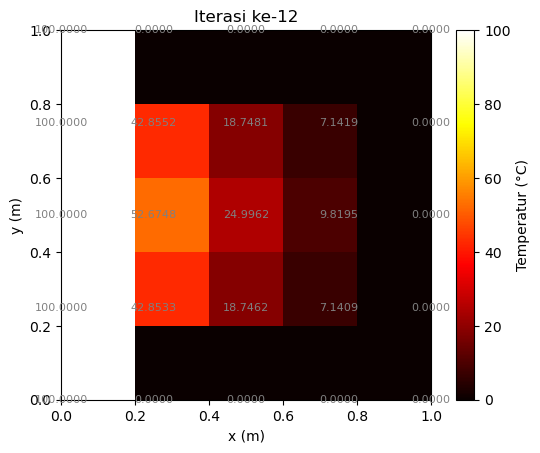

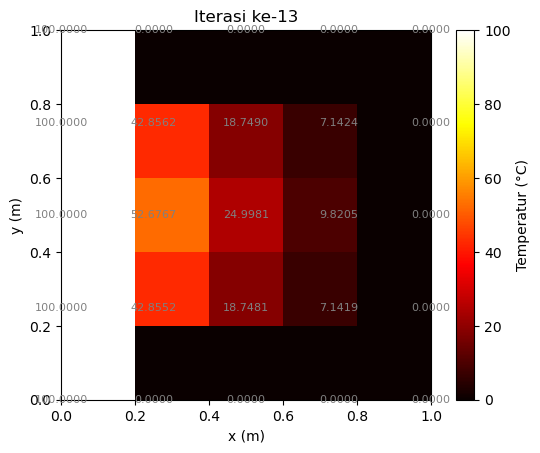

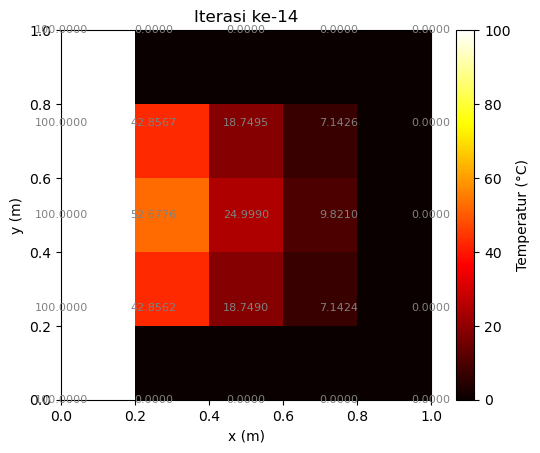

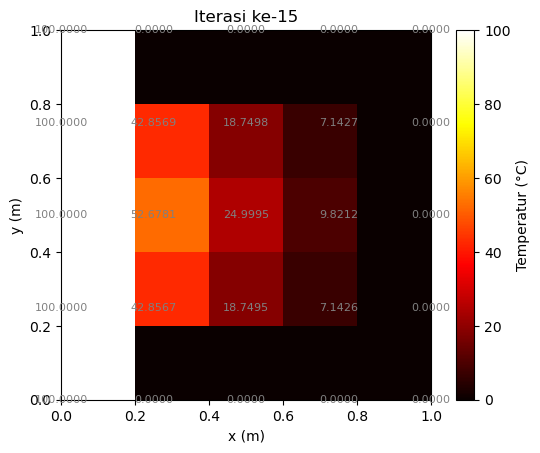

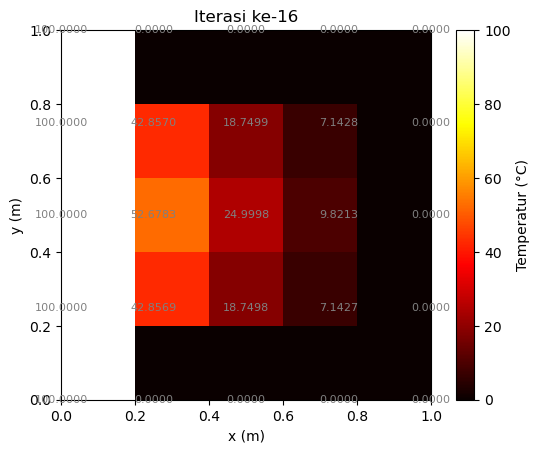

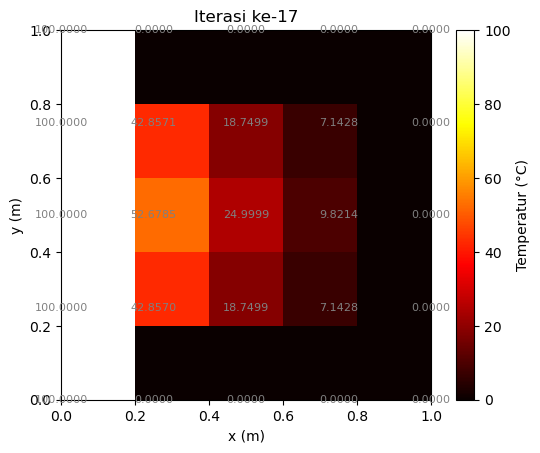

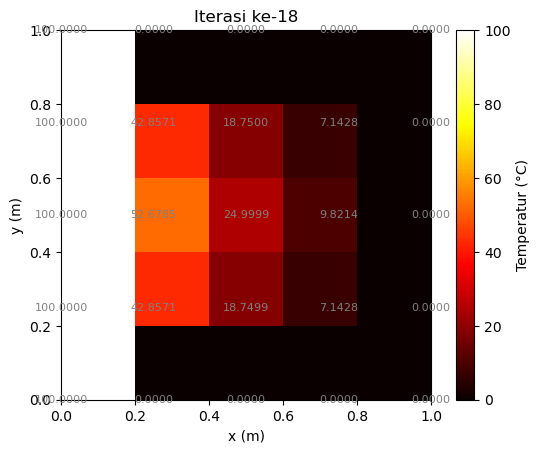

Konvergen setelah 18 iterasi.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

# Parameter grid
L = 1.0       # Panjang pelat (m)
N = 5         # Jumlah titik grid
dx = L / (N - 1)

# Inisialisasi suhu
u = np.zeros((N, N))

# Kondisi batas
u[:, -1] = 0     # Kanan
u[0, :] = 0      # Atas
u[-1, :] = 0     # Bawah
u[:, 0] = 100    # Kiri

# u[N-1, 0] = 50   # Sudut kiri atas
# u[0, 0] = 50     # Sudut kiri bawah

# Fungsi visualisasi per iterasi
def plot_temperature(u, iteration):
    plt.clf()
    plt.imshow(u, origin='lower', cmap='hot', extent=[0, L, 0, L])
    plt.grid(True, color='gray', linestyle='--', alpha=0.5)  # Tambahkan grid
    plt.colorbar(label='Temperatur (°C)')
    plt.title(f'Iterasi ke-{iteration}')
    plt.xlabel('x (m)')
    plt.ylabel('y (m)')

    # Tambahkan nilai numerik di setiap titik
    # i untuk sumbu x (kolom) dan j untuk sumbu y (baris)
    for i in range(N):
        for j in range(N):
            plt.text(i*dx, j*dx, f'{u[j,i]:.4f}', ha='center', va='center', color='gray', fontsize=8)

    plt.pause(0.5)  # jeda 0.5 detik antar iterasi

# Iterasi dengan visualisasi
def steady_state_heat(u, tol=1e-4, max_iter=10000):
    plt.figure(figsize=(6,5))
    for it in range(max_iter):
        u_old = u.copy()
        for i in range(1, N-1):
            for j in range(1, N-1):
                u[j, i] = 0.25 * (u[j+1, i] + u[j-1, i] + u[j, i+1] + u[j, i-1])
        error = np.max(np.abs(u - u_old))
        plot_temperature(u, it)
        if error < tol:
            print(f'Konvergen setelah {it} iterasi.')
            break
    plt.show()
    return u

plot_temperature(u, iteration=-1)
u = steady_state_heat(u)

In [7]:
dx

0.25

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameter grid
L = 1.0       # Panjang pelat (m)
N = 50        # Jumlah titik grid
dx = L / (N - 1)

# Inisialisasi suhu
u = np.zeros((N, N))

# Kondisi batas
u[:, -1] = 0   # Kanan
u[0, :] = 0    # Atas
u[-1, :] = 0   # Bawah
u[:, 0] = 100  # Kiri

# Iterasi metode beda hingga untuk mencapai kondisi tunak
def steady_state_heat(u, tol=1e-4, max_iter=10000):
    for it in range(max_iter):
        u_old = u.copy()
        # Perubahan indeks: i -> x (kolom), j -> y (baris)
        for i in range(1, N-1):
            for j in range(1, N-1):
                # tulis ke u[j, i] (baris j, kolom i)
                u[j, i] = 0.25 * (u[j+1, i] + u[j-1, i] + u[j, i+1] + u[j, i-1])
        error = np.max(np.abs(u - u_old))
        if error < tol:
            print(f'Konvergen setelah {it} iterasi.')
            break
    return u

u = steady_state_heat(u)

# Visualisasi
plt.figure(figsize=(6,5))
plt.imshow(u, origin='lower', cmap='hot', extent=[0, L, 0, L])
plt.grid(True, color='gray', linestyle='--', alpha=0.5)  # Tambahkan grid
plt.colorbar(label='Temperatur (°C)')
plt.title('Distribusi Suhu Tunak 2D')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.show()